# EN3160 Assignment 01

## Intensity Transformations and Neighborhood Filtering

---

**Name:** R.A.C.D. Ranawaka    
**Index Number:** 230526A  
**GitHub Link:** https://github.com/chaniruranawaka/Intensity-Transformations-and-Neighborhood-Filtering


---



### Q1. Intensity Transformation with Breakpoints

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

image_path = "data/input/q1.jpeg"
im = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if im is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

In [ ]:
# Implementing the intensity transformation function
def intensity_transform(im, breakpoints):
    breakpoints = np.asarray(breakpoints, dtype=np.float32)
    input_values = breakpoints[:, 0]
    output_values = breakpoints[:, 1]
    transformed = np.interp(
        im.astype(np.float32),
        input_values,
        output_values
    )
    transformed = np.clip(transformed, 0, 255)
    return transformed.astype(np.uint8)

In [ ]:
# Different Breakpoint Configurations
breakpoints_1a = np.array([[0,   0],[50,  50],[50, 100],[150, 255],[150, 150],[255, 255]])
breakpoints_1 = np.array([[0,   0],[50,  25],[128, 128],[200, 230],[255, 255]])
breakpoints_2 = np.array([[0,   20],[50,  55],[128, 140],[200, 220],[255, 255]])
breakpoints_3 = np.array([[0,   0],[40,  65],[100, 145],[180, 220],[255, 255]])

breakpoint_sets = {"Figure 1a": breakpoints_1a,"Custom 1": breakpoints_1,"Custom 2": breakpoints_2,"Custom 3": breakpoints_3}

# Applying the intensity transformation to the image using different breakpoint configurations
transformed_images = {}
for name, breakpoints in breakpoint_sets.items():
    transformed_images[name] = intensity_transform(im, breakpoints)

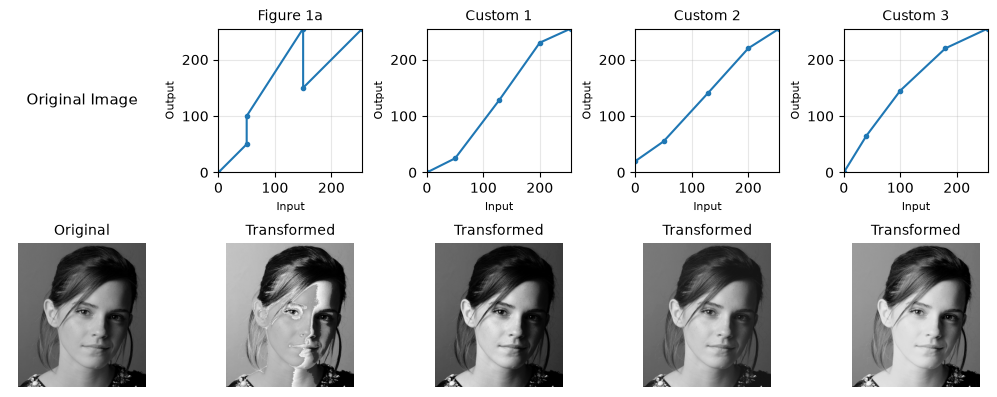

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.


**Observation:** The intensity transformation function was implemented using different breakpoint configurations and applied to the grayscale input image. The resulting transformation curves demonstrate how modifying the input–output intensity relationship can enhance or alter different intensity ranges of the image.

### Q2. Intensity Transformation for Brain Tissue Enhancement

In [ ]:
# Load the image
image_path_q2 = "data/input/q2.jpeg"
brain = cv2.imread(
    image_path_q2,
    cv2.IMREAD_GRAYSCALE
)
if brain is None:
    raise FileNotFoundError(f"Could not load image: {image_path_q2}")

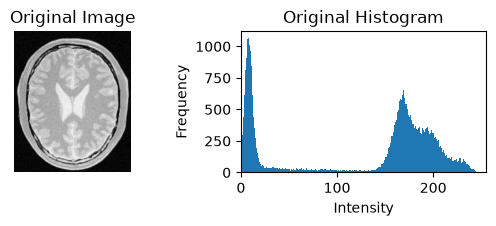

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.


**Observation:** 
The histogram shows a low-intensity region around **0–50**, corresponding mainly to the background, and a broad tissue distribution from approximately **135–251**. Visual inspection shows that **gray matter is prominent around 135–190**, while **white matter is prominent around 190–251**. These ranges are selected for the respective intensity transformations.


#### 2.(a) White Matter

In [ ]:
white_matter_breakpoints = np.array([[0,   0],[135, 0],[190, 30],[251, 255]])

white_matter_enhanced = intensity_transform(
    brain,
    white_matter_breakpoints
)

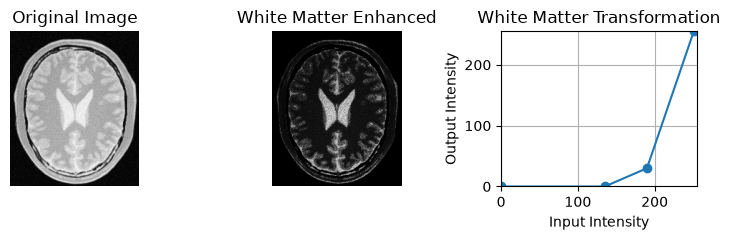

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.


#### 2.(b) Gray Matter

In [141]:
# Breakpoints for gray matter enhancement
gray_matter_breakpoints = np.array([[0,   0],[135, 30],[190, 230],[251, 255]])

# Apply gray matter intensity transformation
gray_matter_enhanced = intensity_transform(
    brain,
    gray_matter_breakpoints
)

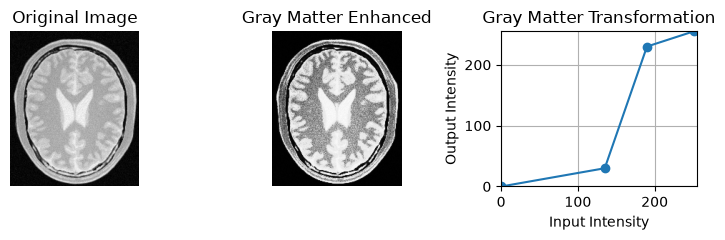

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.


**Observation:** The piecewise-linear intensity transformations successfully accentuated the desired brain tissues. The 135–190 intensity range enhanced the visibility of gray matter, while the 190–251 range emphasized white matter by increasing the contrast within each selected intensity range.


### Q3. Gamma Correction

In [ ]:
image_path_q3 = "data/input/WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg"
image = cv2.imread(image_path_q3)
if image is None:
    raise FileNotFoundError(f"Could not load image: {image_path_q3}")

* The image is converted from BGR to L* a* b* color space, and the L* plane is extracted for gamma correction.

In [ ]:
# Convert BGR image to L*a*b* color space
lab = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2LAB
)
# Split into L*, a*, and b* planes
L, a, b = cv2.split(lab)

#### 3.(a) Apply gamma correction

In [ ]:
# Gamma values to compare
gamma_values = [0.5, 0.7, 0.9, 1.0, 1.2]
gamma_results = {}
for gamma in gamma_values:
    # Normalize L* to [0, 1]
    L_normalized = L / 255.0
    # Apply gamma correction
    L_gamma = np.power(
        L_normalized,
        gamma
    )
    # Convert back to 8-bit
    L_corrected = np.uint8(
        L_gamma * 255
    )
    # Store result
    gamma_results[gamma] = L_corrected

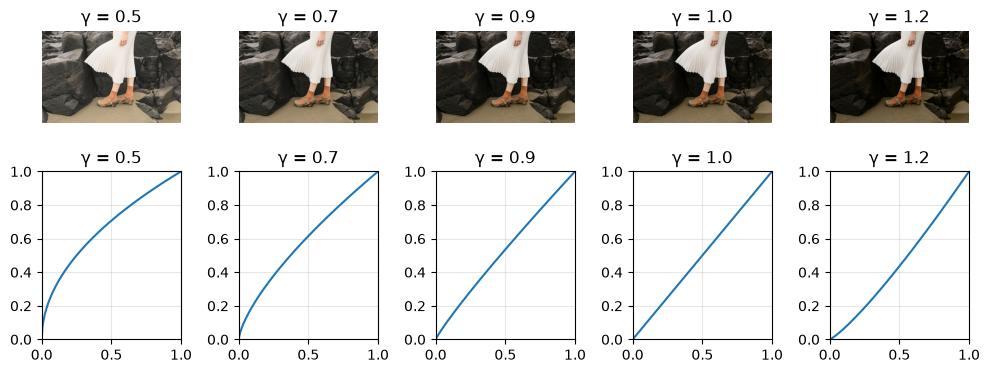

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

**Observation:** The results show that decreasing γ below 1 increases the brightness of the image, while increasing γ above 1 produces a darker result. The transformation curves also show this change in the mapping of L* intensity values.

* Among the tested values, γ = 0.7 provides the most suitable enhancement for the given image.

#### 3.(b) Histograms of original and gamma corrected image

In [ ]:
gamma = 0.7
# Apply gamma correction to L*
L_corrected = np.uint8(
    (L / 255.0) ** gamma * 255
)
# Reconstruct L*a*b*
lab_corrected = cv2.merge([
    L_corrected,
    a,
    b
])
# Convert back to BGR
corrected_image = cv2.cvtColor(
    lab_corrected,
    cv2.COLOR_LAB2BGR
)

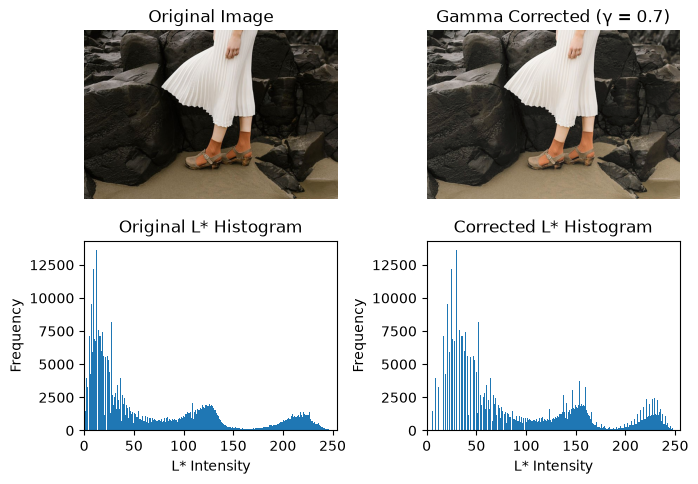

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

**Observation:** With **γ = 0.7**, the darker L* intensity values are expanded, resulting in a brighter image. The corrected histogram shows the corresponding shift of the L* intensity distribution toward higher values.


### Q4. Vibrance Enhancement

In [ ]:
# Load image
image = cv2.imread("data/input/WhatsApp Image 2026-09-09 at 20.02.441.jpeg")

#### 4.(a) Split the Image into Hue, Saturation and Value Planes

In [ ]:
# Convert BGR to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# Split into H, S, V planes
H, S, V = cv2.split(hsv)

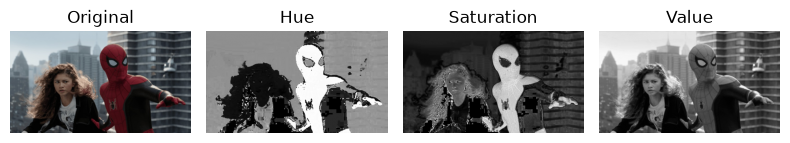

In [43]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 4.(b) Apply the intensity transformation

In [ ]:
sigma = 70
a = 0.5
# Apply transformation to saturation plane
x = S.astype(np.float32)
S_new = np.minimum(
    x + a * 128 * np.exp(-(x - 128)**2 / (2 * sigma**2)),
    255
).astype(np.uint8)

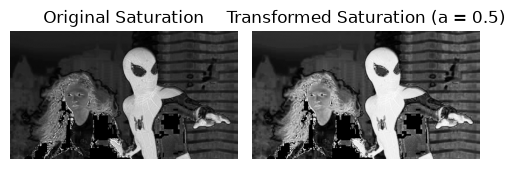

In [44]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 4.(c) Adjust a

In [ ]:
a_values = [0.2, 0.4, 0.6, 0.8, 1.0]
sigma = 70
results = []
for a in a_values:
    x = S.astype(np.float32)
    S_new = np.minimum(
        x + a * 128 * np.exp(-(x - 128)**2 / (2 * sigma**2)),
        255
    ).astype(np.uint8)
    hsv_new = cv2.merge([H, S_new, V])
    result = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2BGR)
    results.append((a, result))

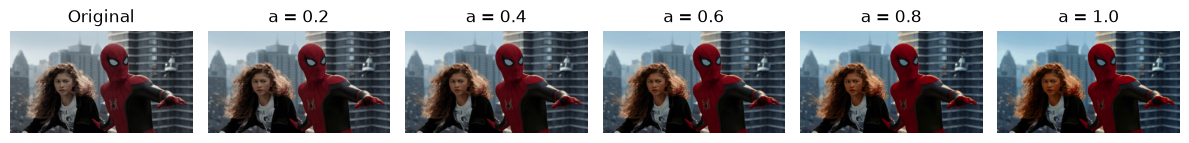

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

* After comparing several values of (a), (a = 0.4) was selected as it provided a visually pleasing increase in image vibrance while maintaining natural-looking colors.

#### 4.(d) Recombine the Three Planes

In [ ]:
a = 0.4
sigma = 70
# Transform saturation plane
x = S.astype(np.float32)
S_new = np.minimum(
    x + a * 128 * np.exp(-(x - 128)**2 / (2 * sigma**2)),
    255
).astype(np.uint8)
# Recombine H, transformed S, and V
hsv_enhanced = cv2.merge([H, S_new, V])
# Convert back to BGR
vibrance_image = cv2.cvtColor(
    hsv_enhanced,
    cv2.COLOR_HSV2BGR
)

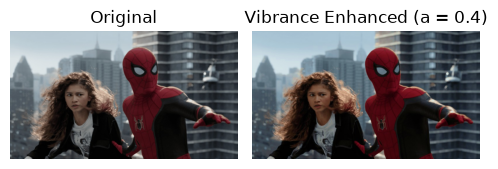

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 4.(e) Final Result

In [ ]:
# Intensity transformation curve
x = np.arange(256)
transformation = np.minimum(
    x + a * 128 * np.exp(-(x - 128)**2 / (2 * sigma**2)),
    255
)

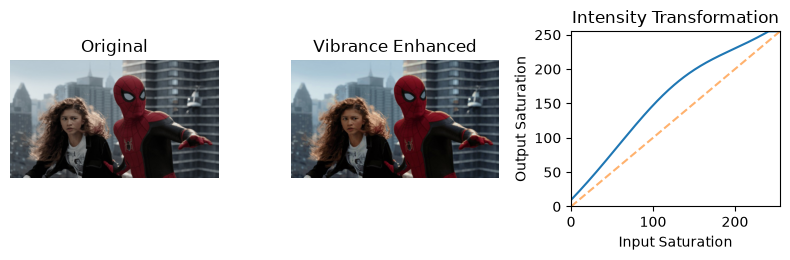

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

**Observation:** The saturation enhancement with **\(a=0.4\)** increased the vibrance of the image while maintaining a visually natural appearance. The nonlinear transformation primarily increases saturation around the middle intensity range while limiting the output to 255.


### Q5. Histogram Equalization

In [ ]:
def histogram_equalization(image):
    # Calculate histogram
    hist = np.bincount(image.ravel(), minlength=256)
    # Calculate cumulative distribution function
    cdf = hist.cumsum()
    # Normalize CDF
    cdf_min = cdf[cdf > 0][0]
    cdf_normalized = (cdf - cdf_min) * 255 / (cdf[-1] - cdf_min)
    # Create intensity mapping
    mapping = np.clip(cdf_normalized, 0, 255).astype(np.uint8)
    # Apply mapping
    equalized = mapping[image]
    return equalized

In [ ]:
# Load image
image = cv2.imread("data/input/shells.tif")
imageGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Apply custom histogram equalization
equalized_image = histogram_equalization(imageGray)

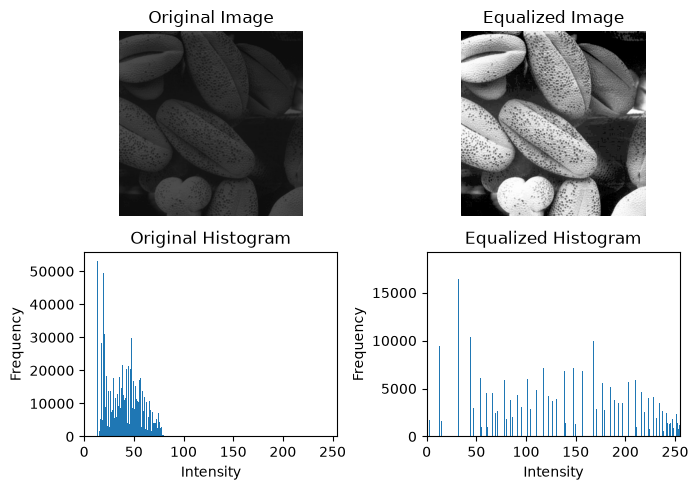

In [54]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

**Observation:** Histogram equalization redistributed the image intensity values over a wider range, improving the overall contrast. The equalized histogram shows a more evenly distributed intensity range compared with the original histogram.


### Q6. Foreground-only histogram equalization

In [55]:
# Load image
image = cv2.imread("data/input/WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg")

#### 6.(a) Split into H, S, V planes

In [ ]:
# Convert to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# Split planes
H, S, V = cv2.split(hsv)

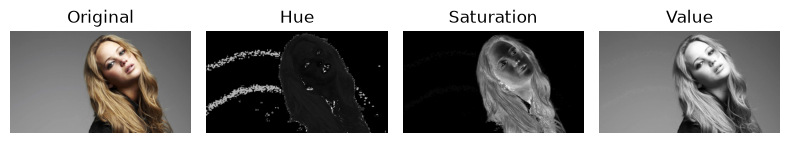

In [56]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 6.(b) Foreground Mask

* The Saturation (S) plane was selected for thresholding because it provided the best separation between the foreground and background. A binary threshold was applied to obtain the foreground mask.

In [ ]:
# Threshold the Saturation plane
threshold = 10
_, mask = cv2.threshold(S,threshold,255,cv2.THRESH_BINARY)

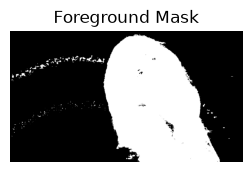

In [69]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 6.(c) Extract the Foreground and Compute Histogram

In [ ]:
# Extract foreground using the mask
foreground = cv2.bitwise_and(V,V,mask=mask)

# Compute foreground histogram
hist = np.bincount(foreground[mask > 0],minlength=256)

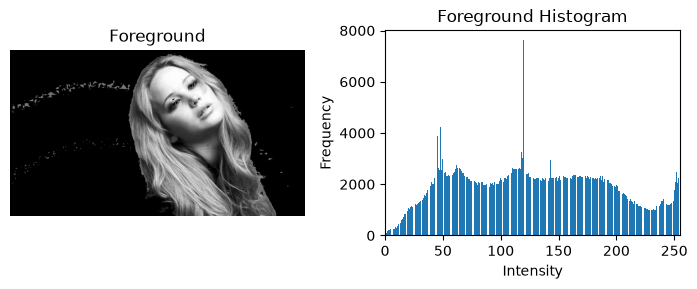

In [70]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 6.(d) Cumulative Sum of the Histogram

In [ ]:
# Calculate cumulative distribution function
cdf = np.cumsum(hist)

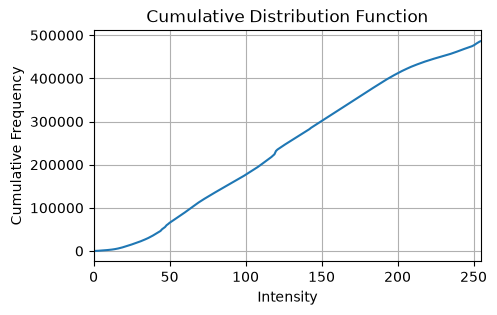

In [71]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 6.(e) Histogram Equalization of the Foreground

In [ ]:
# Find the first non-zero CDF value
cdf_min = cdf[cdf > 0][0]
# Normalize CDF to 0-255
mapping = ((cdf - cdf_min) * 255 / (cdf[-1] - cdf_min))
mapping = np.clip(mapping, 0, 255).astype(np.uint8)

# Apply equalization only to foreground pixels
equalized_foreground = foreground.copy()
equalized_foreground[mask > 0] = mapping[
    foreground[mask > 0]
]

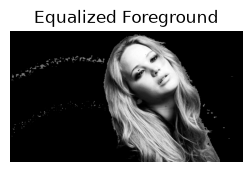

In [72]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 6.(f) Combine Equalized Foreground with Background

In [ ]:
# Extract background
background = cv2.bitwise_and(V,V, mask=cv2.bitwise_not(mask)
)
# Combine background with equalized foreground
V_final = background + equalized_foreground
# Recombine HSV planes
hsv_final = cv2.merge([H, S, V_final])
# Convert back to BGR
result = cv2.cvtColor(hsv_final, cv2.COLOR_HSV2BGR)

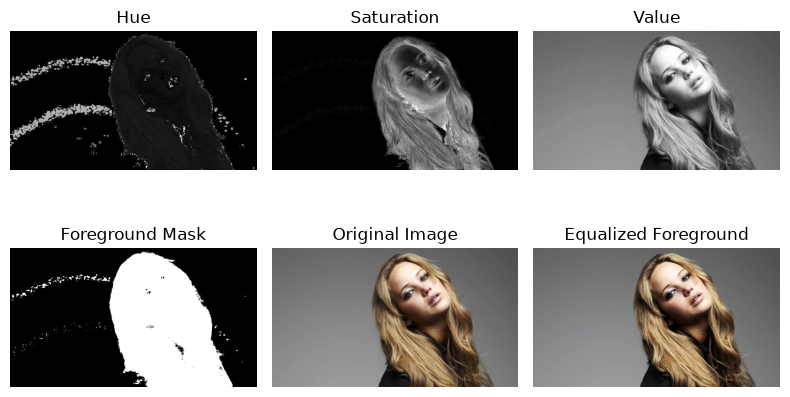

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

**Observation:** Histogram equalization was applied only to the extracted foreground while the background was preserved. The final image therefore shows enhanced contrast in the foreground without significantly altering the background.


### Q7. Sobel Filtering

In [74]:
# Load image as grayscale
image = cv2.imread("data/input/WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg", cv2.IMREAD_GRAYSCALE)

#### 7.(a) Sobel Filtering Using filter2D

In [ ]:
# Sobel kernels
Gx_kernel = np.array([[1, 0, -1],[2, 0, -2],[1, 0, -1]])
Gy_kernel = np.array([[1, 2, 1],[0, 0, 0],[-1, -2, -1]])
# Apply Sobel filtering using filter2D
Gx = cv2.filter2D(image, cv2.CV_64F, Gx_kernel)
Gy = cv2.filter2D(image, cv2.CV_64F, Gy_kernel)
# Gradient magnitude
magnitude = np.sqrt(Gx**2 + Gy**2)

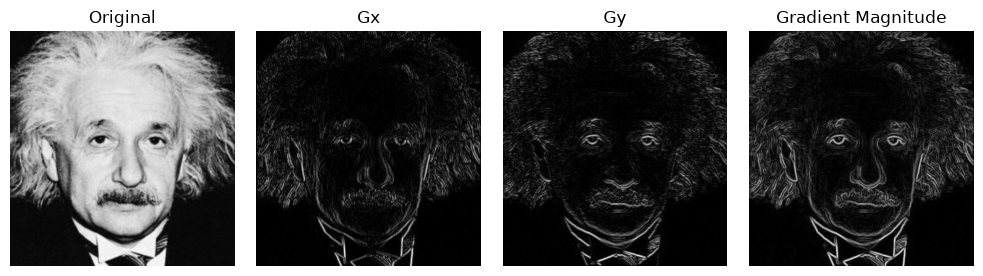

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 7.(b) Implementing the Sobel Filter

In [ ]:
def sobel_filter(image, kernel):
    padded = np.pad(image, 1, mode="edge")
    output = np.zeros_like(image, dtype=np.float64)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+3, j:j+3]
            output[i, j] = np.sum(region * kernel)

    return output
# Apply custom Sobel filtering
Gx_custom = sobel_filter(image, Gx_kernel)
Gy_custom = sobel_filter(image, Gy_kernel)
# Gradient magnitude
magnitude_custom = np.sqrt(
    Gx_custom**2 + Gy_custom**2
)

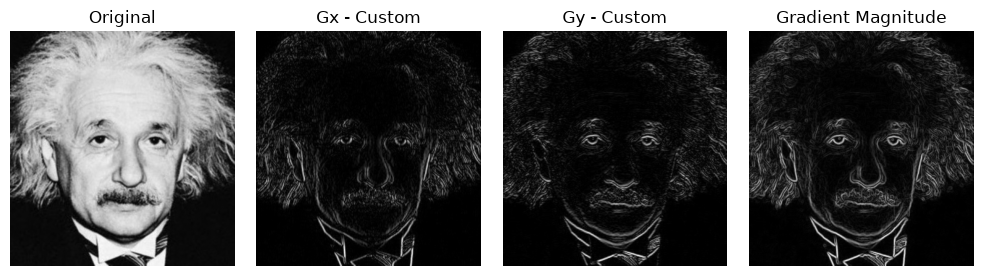

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 7.(c) Sobel Filtering Using Separable Kernels

In [ ]:
# 1D Sobel filters
smooth = np.array([1, 2, 1], dtype=np.float64)
derivative = np.array([1, 0, -1], dtype=np.float64)
# Gx = [1 2 1]^T * [1 0 -1]
temp = cv2.filter2D(image,cv2.CV_64F,smooth.reshape(-1, 1))
Gx_sep = cv2.filter2D(temp,cv2.CV_64F,derivative.reshape(1, -1))
# Gy = [1 2 1] * [1 0 -1]^T
temp = cv2.filter2D(image,cv2.CV_64F,smooth.reshape(1, -1))
Gy_sep = cv2.filter2D(temp,cv2.CV_64F,derivative.reshape(-1, 1))
# Gradient magnitude
magnitude_sep = np.sqrt(Gx_sep**2 + Gy_sep**2)

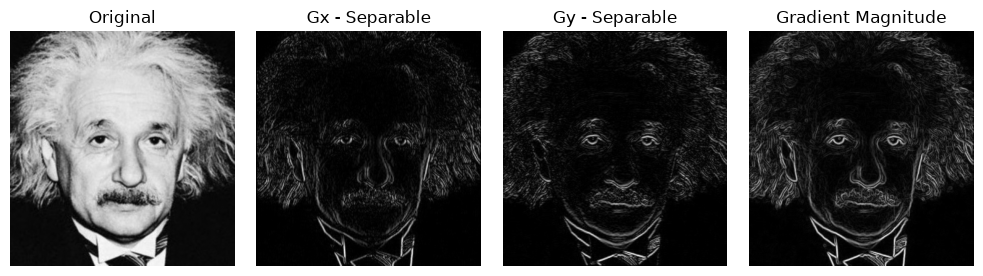

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

**Observation:** The (G_x) and (G_y) images highlight intensity changes in the horizontal and vertical directions, respectively. The gradient magnitude combines these responses and clearly emphasizes the edges in the image. The results from the three implementations are visually very similar, confirming that the custom and separable implementations correctly reproduce the Sobel filtering operation.

### Q8. Image Zooming

In [ ]:
# Implementing image zooming with nearest neighbor and bilinear interpolation
def zoom_image(image, scale, method="nearest"):
    if scale <= 0 or scale > 10:
        raise ValueError("Scale factor must be in the range (0, 10].")
    h, w = image.shape[:2]
    new_h = int(round(h * scale))
    new_w = int(round(w * scale))
    zoomed = np.zeros(
        (new_h, new_w) + image.shape[2:],
        dtype=np.float64
    )
    for y in range(new_h):
        src_y = y / scale
        for x in range(new_w):
            src_x = x / scale
            if method == "nearest":
                iy = min(int(round(src_y)), h - 1)
                ix = min(int(round(src_x)), w - 1)
                zoomed[y, x] = image[iy, ix]
            elif method == "bilinear":
                y0 = int(np.floor(src_y))
                x0 = int(np.floor(src_x))
                y1 = min(y0 + 1, h - 1)
                x1 = min(x0 + 1, w - 1)
                dy = src_y - y0
                dx = src_x - x0
                top = (
                    (1 - dx) * image[y0, x0]
                    + dx * image[y0, x1]
                )
                bottom = (
                    (1 - dx) * image[y1, x0]
                    + dx * image[y1, x1]
                )
                zoomed[y, x] = (
                    (1 - dy) * top
                    + dy * bottom
                )
            else:
                raise ValueError(
                    "Method must be 'nearest' or 'bilinear'."
                )
    return np.clip(zoomed, 0, 255).astype(image.dtype)

In [ ]:
def normalized_ssd(original, reconstructed):
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)
    # Match reconstructed image size to original
    h, w = original.shape[:2]
    reconstructed = reconstructed[:h, :w]
    ssd = np.sum(
        (original - reconstructed) ** 2
    )
    return ssd / np.sum(original ** 2)

In [ ]:
original1 = cv2.imread("data/input/im01.png")
small1 = cv2.imread("data/input/im01small.png")
original2 = cv2.imread("data/input/im02.png")
small2 = cv2.imread("data/input/im02small.png")
original3 = cv2.imread("data/input/im03.png")
small3 = cv2.imread("data/input/im03small.png")
original4 = cv2.imread("data/input/im04.jpg")
small4 = cv2.imread("data/input/im04small.jpg")
# Store the four image pairs
pairs = [
    (original1, small1, "Image 1"),
    (original2, small2, "Image 2"),
    (original3, small3, "Image 3"),
    (original4, small4, "Image 4")
]

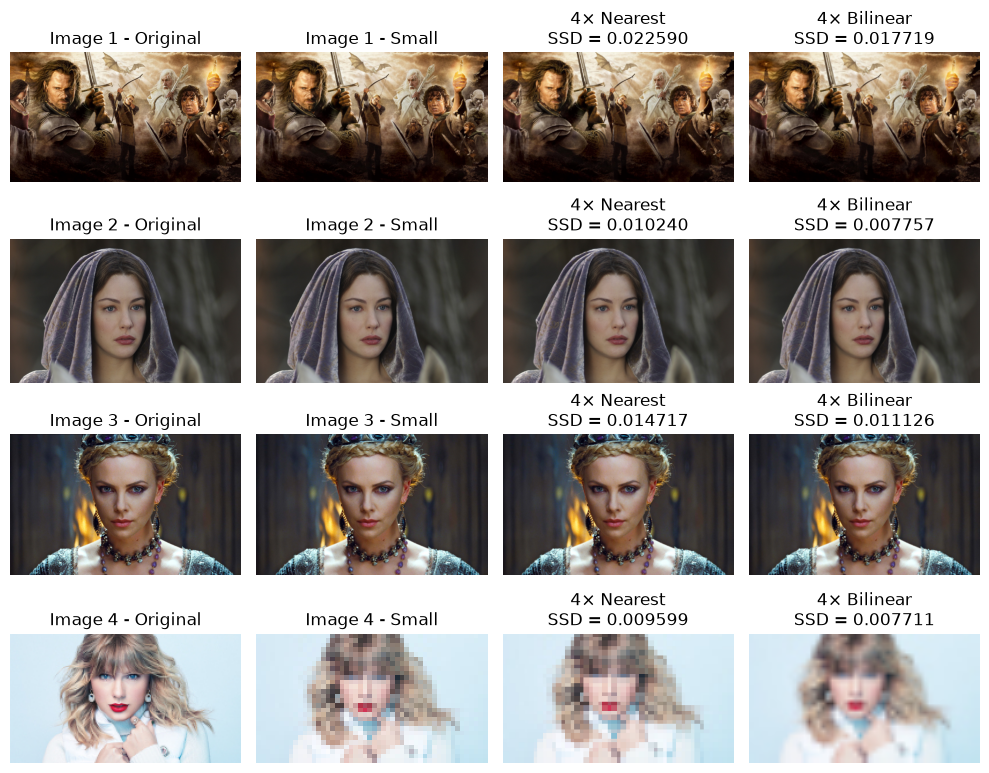

In [ ]:
fig, axes = plt.subplots(
    4, 4,
    figsize=(10, 8)
)
for row, (original, small, name) in enumerate(pairs):
    # 4× zoom using nearest-neighbor
    nearest = zoom_image(
        small,
        4,
        method="nearest"
    )
    # 4× zoom using bilinear interpolation
    bilinear = zoom_image(
        small,
        4,
        method="bilinear"
    )
    # Calculate normalized SSD
    ssd_nearest = normalized_ssd(
        original,
        nearest
    )
    ssd_bilinear = normalized_ssd(
        original,
        bilinear
    )
    # Original
    axes[row, 0].imshow(
        cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    )
    axes[row, 0].set_title(f"{name} - Original")
    axes[row, 0].axis("off")

    # Small image
    axes[row, 1].imshow(
        cv2.cvtColor(small, cv2.COLOR_BGR2RGB)
    )
    axes[row, 1].set_title(f"{name} - Small")
    axes[row, 1].axis("off")

    # Nearest neighbor
    axes[row, 2].imshow(
        cv2.cvtColor(nearest, cv2.COLOR_BGR2RGB)
    )
    axes[row, 2].set_title(
        f"4× Nearest\nSSD = {ssd_nearest:.6f}"
    )
    axes[row, 2].axis("off")

    # Bilinear
    axes[row, 3].imshow(
        cv2.cvtColor(bilinear, cv2.COLOR_BGR2RGB)
    )
    axes[row, 3].set_title(
        f"4× Bilinear\nSSD = {ssd_bilinear:.6f}"
    )
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()

**Observation:** The four small images were scaled up by a factor of 4 using both nearest-neighbor and bilinear interpolation. The reconstructed images were compared with their corresponding original images using the normalized Sum of Squared Differences (SSD). A lower normalized SSD indicates a smaller reconstruction error and therefore better agreement with the original image.

### Q9. GrabCut and background blur

In [ ]:
image = cv2.imread("data/input/WhatsApp Image 2026-09-09 at 20.02.43 (1).jpeg")
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

#### 9.(a) GrabCut Segmentation

In [ ]:
# Define the rectangle for cropping
h, w = image.shape[:2]
rect = (int(0.05 * w),  int(0.05 * h),  int(0.90 * w),  int(0.90 * h)    )

In [ ]:
# Create a mask for GrabCut
mask = np.zeros(image.shape[:2],np.uint8)
bgd_model = np.zeros((1, 65),np.float64)
fgd_model = np.zeros((1, 65),np.float64)
cv2.grabCut(image,mask,rect,bgd_model,fgd_model,5,cv2.GC_INIT_WITH_RECT)

In [ ]:
foreground_mask = np.where((mask == cv2.GC_FGD) |(mask == cv2.GC_PR_FGD),255,0).astype(np.uint8)
foreground = cv2.bitwise_and(image,image,mask=foreground_mask)
background_mask = cv2.bitwise_not(foreground_mask)
background = cv2.bitwise_and(image,image,mask=background_mask)

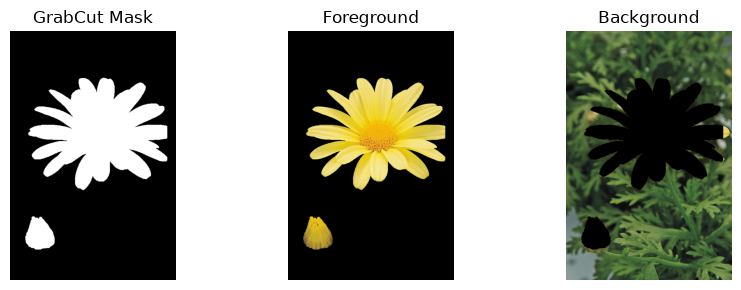

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 9.(b) Blur the Background

In [ ]:
# Blur the original image using Gaussian blur
blurred = cv2.GaussianBlur(image,(51, 51),0)

In [ ]:
foreground_part = cv2.bitwise_and(image,image,mask=foreground_mask)
background_part = cv2.bitwise_and(blurred,blurred,mask=background_mask)
enhanced = cv2.add(foreground_part,background_part)

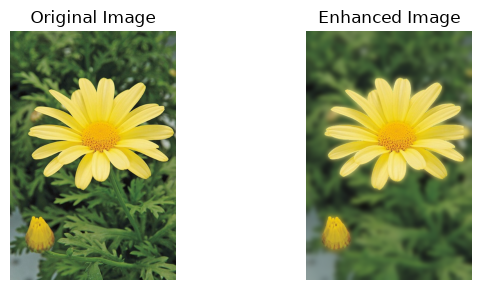

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 9.(c) Why does the background near the flower become dark?

* The dark region just beyond the edge of the flower is caused by the Gaussian blurring of pixels near the foreground boundary. During GrabCut segmentation, some pixels around the flower edge may be classified as background. These pixels are therefore replaced by the blurred background, where intensity values from the darker surrounding background are averaged with nearby pixels. This produces a darker transition around parts of the flower boundary.

### Q10. Gaussian and bilateral filtering

In [121]:
image = cv2.imread("data/input/WhatsApp Image 2026-09-09 at 20.02.44 (3).jpeg")

#### 10.(a) Bilateral Filtering Using OpenCV

In [ ]:
# Bilateral filter parameters
kernel_size = 9
sigma_s = 75
sigma_r = 75
# Gaussian blur with similar spatial scale
gaussian = cv2.GaussianBlur(image,(kernel_size, kernel_size),sigma_s)
# OpenCV bilateral filter
bilateral = cv2.bilateralFilter(image,kernel_size,sigma_r,sigma_s)

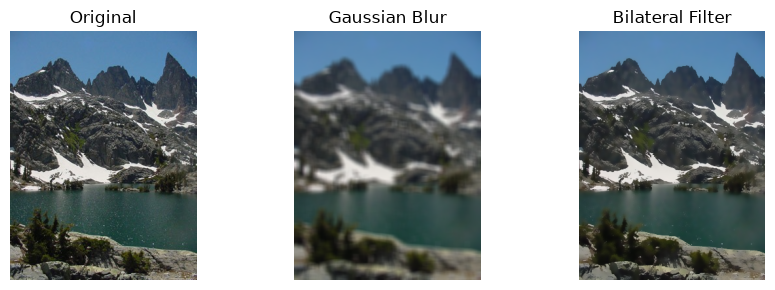

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

#### 10.(b) Custom Bilateral Filter

In [ ]:
def bilateral_filter(image, kernel_size, sigma_s, sigma_r):
    image = image.astype(np.float64)
    pad = kernel_size // 2
    padded = np.pad(
        image,
        pad,
        mode="edge"
    )
    h, w = image.shape
    output = np.zeros(
        (h, w),
        dtype=np.float64
    )
    # Coordinate grid for spatial Gaussian
    y, x = np.mgrid[
        -pad:pad+1,
        -pad:pad+1
    ]
    spatial = np.exp(
        -(x**2 + y**2) /
        (2 * sigma_s**2)
    )
    for i in range(h):
        for j in range(w):
            region = padded[
                i:i + kernel_size,
                j:j + kernel_size
            ]
            # Range / intensity weights
            intensity_difference = (
                region - image[i, j]
            )
            range_weights = np.exp(
                -(intensity_difference**2) /
                (2 * sigma_r**2)
            )
            # Combined bilateral weights
            weights = (
                spatial *
                range_weights
            )
            # Weighted average
            output[i, j] = np.sum(
                weights * region
            ) / np.sum(weights)

    return np.clip(output,0,255).astype(np.uint8)

In [ ]:
gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)
custom_bilateral = bilateral_filter(gray,kernel_size=9,sigma_s=75,sigma_r=75)
opencv_bilateral = cv2.cvtColor(bilateral,cv2.COLOR_BGR2GRAY)
gaussian_gray = cv2.cvtColor(gaussian,cv2.COLOR_BGR2GRAY)

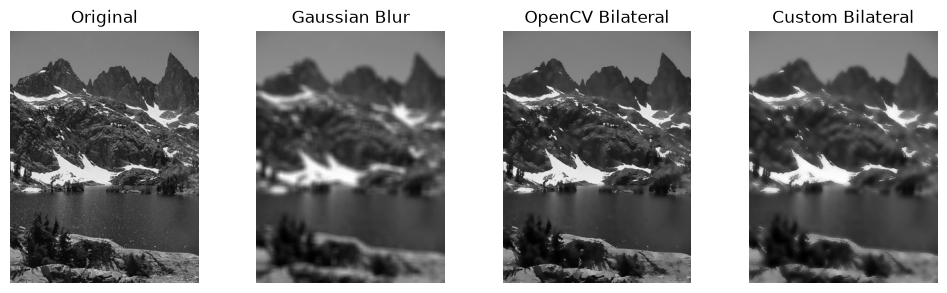

In [ ]:
# Note: The figure-generating code for selected figures has been removed from the final notebook to reduce the overall page count of the report. The corresponding results and figures are retained.

In [ ]:
mse = np.mean(
    (opencv_bilateral.astype(np.float64)
     - custom_bilateral.astype(np.float64)) ** 2
)
print(f"MSE between OpenCV and Custom Bilateral Filter: {mse:.6f}")

MSE between OpenCV and Custom Bilateral Filter: 120.963204


In [ ]:
psnr = cv2.PSNR(
    opencv_bilateral,
    custom_bilateral
)
print(f"PSNR between OpenCV and Custom Bilateral Filter: {psnr:.2f} dB")

PSNR between OpenCV and Custom Bilateral Filter: 27.30 dB


**Observation:** The Gaussian filter smooths both homogeneous regions and strong edges, resulting in noticeable edge blurring. In contrast, the bilateral filter reduces noise and smooths relatively uniform regions while preserving important intensity boundaries. The custom bilateral filter produces a result similar to OpenCV's implementation, which can be verified quantitatively using the MSE and PSNR values.
